# Segunda Semana — Creación del dataset en PyTorch para Google Colab

**Proyecto:** Road Damage Detection  
**Dataset:** Road Damage Dataset: Potholes, Cracks and Manholes  
**Fuente:** Kaggle  
**Tarea:** detección de objetos con anotaciones YOLO

Este notebook está organizado según las secciones pedidas para la exposición:

- a) Carga y organización del dataset
- b) Particionado
- c) Preprocesamiento
- d) Data augmentation
- e) Verificación final

> En Google Colab, ejecutar las celdas en orden. Si Kaggle solicita credenciales, subir el archivo `kaggle.json` cuando corresponda.

## 0. Instalación de dependencias para Colab

Ejecutar esta celda al inicio del notebook.


In [ ]:
# Instalación de dependencias necesarias en Google Colab
!pip -q install torch torchvision torchaudio
!pip -q install ultralytics albumentations opencv-python matplotlib pandas scikit-learn pillow kagglehub tqdm pyyaml


## 0.1 Imports, configuración y semilla

Fijamos una semilla para que el particionado sea reproducible.


In [ ]:
from pathlib import Path
import os
import random
import shutil
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/Proyecto_Deteccion')

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

METADATA_PATH = DATA_DIR / "metadata.csv"
TRAIN_CSV = DATA_DIR / "train.csv"
VAL_CSV = DATA_DIR / "val.csv"
TEST_CSV = DATA_DIR / "test.csv"

DATASET_SLUG = "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"

CLASS_NAMES = {
    0: "Pothole",
    1: "Crack",
    2: "Manhole",
}

IMG_SIZE = 640
BATCH_SIZE = 8

# Modo de preprocesamiento:
# - "resize_pad": reduce imágenes grandes manteniendo proporción y agrega padding hasta 640x640.
# - "safe_crop_resize": opción experimental para train; intenta recortar preservando cajas.
PREPROCESS_MODE = "resize_pad"

# Banderas para NO tocar el dataset cada vez que se entrena.
# Dejarlas en False para reutilizar metadata/splits si ya existen.
FORCE_REGENERATE_METADATA = False
FORCE_REGENERATE_SPLITS = False

# Configuración de balanceo de clases.
# A mayor CLASS_WEIGHT_POWER, más se castiga el error en clases minoritarias.
# MAX_CLASS_WEIGHT evita pesos extremos que vuelvan inestable el entrenamiento.
CLASS_WEIGHT_POWER = 1.0
MAX_CLASS_WEIGHT = 10.0
NO_OBJECT_SAMPLE_WEIGHT = 0.25

DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RAW_DIR:", RAW_DIR)
print("METADATA_PATH:", METADATA_PATH)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("TEST_CSV:", TEST_CSV)
print("FORCE_REGENERATE_METADATA:", FORCE_REGENERATE_METADATA)
print("FORCE_REGENERATE_SPLITS:", FORCE_REGENERATE_SPLITS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/Proyecto_Deteccion
DATA_DIR: /content/drive/MyDrive/Proyecto_Deteccion/data
RAW_DIR: /content/drive/MyDrive/Proyecto_Deteccion/data/raw
METADATA_PATH: /content/drive/MyDrive/Proyecto_Deteccion/data/metadata.csv
TRAIN_CSV: /content/drive/MyDrive/Proyecto_Deteccion/data/train.csv
VAL_CSV: /content/drive/MyDrive/Proyecto_Deteccion/data/val.csv
TEST_CSV: /content/drive/MyDrive/Proyecto_Deteccion/data/test.csv
FORCE_REGENERATE_METADATA: True
FORCE_REGENERATE_SPLITS: True


# a) Carga y organización del dataset

En esta sección se descarga el dataset desde Kaggle, se define la estructura de carpetas y se construye un `metadata.csv` con la relación entre imágenes y etiquetas YOLO.




In [ ]:
def download_dataset_with_kagglehub(dataset_slug: str, destination: Path) -> Path:
    """Descarga el dataset con kagglehub y copia el contenido a data/raw/.

    Si ya hay imágenes en data/raw/, no vuelve a descargar ni modificar el dataset.
    """
    existing_images = list(destination.rglob("*.jpg")) + list(destination.rglob("*.jpeg")) + list(destination.rglob("*.png"))
    if existing_images:
        print(f"Ya existen {len(existing_images)} imágenes en {destination}. No se descarga ni se copia nuevamente.")
        return destination

    import kagglehub

    print("Descargando dataset desde Kaggle...")
    downloaded_path = Path(kagglehub.dataset_download(dataset_slug))
    print("Dataset descargado en cache:", downloaded_path)

    print("Copiando archivos a:", destination)
    for item in downloaded_path.iterdir():
        target = destination / item.name
        if item.is_dir():
            if target.exists():
                shutil.rmtree(target)
            shutil.copytree(item, target)
        else:
            shutil.copy2(item, target)

    return destination


RAW_DIR = download_dataset_with_kagglehub(DATASET_SLUG, RAW_DIR)


Ya existen 2009 imágenes en /content/drive/MyDrive/Proyecto_Deteccion/data/raw. No se descarga ni se copia nuevamente.


## Exploración de carpetas y lectura de etiquetas YOLO

En este dataset las etiquetas pueden venir en dos variantes:

```text
Formato YOLO detección:
clase x_centro y_centro ancho alto
```

o como polígonos de segmentación:

```text
Formato YOLO segmentación:
clase x1 y1 x2 y2 x3 y3 x4 y4 ...
```

Para este proyecto de detección, si la etiqueta viene como polígono, se convierte automáticamente a una **bounding box** tomando el mínimo y máximo de las coordenadas `x` e `y`.

Las coordenadas están normalizadas entre 0 y 1.


In [ ]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_dataset_files(root: Path):
    images = sorted([p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
    labels = sorted([p for p in root.rglob("*.txt")])
    return images, labels

images, labels = list_dataset_files(RAW_DIR)

print("Cantidad de imágenes encontradas:", len(images))
print("Cantidad de archivos .txt encontrados:", len(labels))

print("\nPrimeras imágenes:")
for p in images[:5]:
    print(" -", p.relative_to(PROJECT_ROOT))

print("\nPrimeras etiquetas:")
for p in labels[:5]:
    print(" -", p.relative_to(PROJECT_ROOT))

Cantidad de imágenes encontradas: 2009
Cantidad de archivos .txt encontrados: 4018

Primeras imágenes:
 - data/raw/data/images/20250216_164325.jpg
 - data/raw/data/images/20250216_164521.jpg
 - data/raw/data/images/20250216_164541.jpg
 - data/raw/data/images/20250219_164649.jpg
 - data/raw/data/images/20250219_164714.jpg

Primeras etiquetas:
 - data/raw/data/labels/20250216_164325.txt
 - data/raw/data/labels/20250216_164521.txt
 - data/raw/data/labels/20250216_164541.txt
 - data/raw/data/labels/20250219_164649.txt
 - data/raw/data/labels/20250219_164714.txt


In [ ]:
def find_label_for_image(image_path: Path, root: Path):
    """
    Busca el archivo .txt correspondiente a una imagen.
    """
    # 1) Mismo directorio
    direct = image_path.with_suffix(".txt")
    if direct.exists():
        return direct

    # 2) Reemplazar carpeta images por labels
    parts = list(image_path.parts)

    if "images" in parts:
        idx = parts.index("images")
        parts[idx] = "labels"
        candidate = Path(*parts).with_suffix(".txt")
        if candidate.exists():
            return candidate

    if "Images" in parts:
        idx = parts.index("Images")
        parts[idx] = "Labels"
        candidate = Path(*parts).with_suffix(".txt")
        if candidate.exists():
            return candidate

    # 3) Búsqueda global por nombre
    candidates = list(root.rglob(image_path.stem + ".txt"))
    candidates = [
        c for c in candidates
        if c.name.lower() not in ["classes.txt", "obj.names", "readme.txt"]
    ]

    if candidates:
        return candidates[0]

    return None


def clip_yolo_bbox(x_center, y_center, width, height, eps: float = 1e-6):
    """Corrige una caja YOLO para que Albumentations no falle.
    """
    try:
        x_center = float(x_center)
        y_center = float(y_center)
        width = float(width)
        height = float(height)
    except (TypeError, ValueError):
        return None

    if not np.isfinite([x_center, y_center, width, height]).all():
        return None

    if width <= 0 or height <= 0:
        return None

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    x_min = min(max(x_min, 0.0), 1.0)
    y_min = min(max(y_min, 0.0), 1.0)
    x_max = min(max(x_max, 0.0), 1.0)
    y_max = min(max(y_max, 0.0), 1.0)

    new_width = x_max - x_min
    new_height = y_max - y_min

    if new_width <= eps or new_height <= eps:
        return None

    new_x_center = x_min + new_width / 2
    new_y_center = y_min + new_height / 2

    return [new_x_center, new_y_center, new_width, new_height]


def sanitize_yolo_bboxes_and_labels(bboxes, labels):
    """Aplica clip seguro a una lista de bboxes y mantiene labels alineadas."""
    clean_bboxes = []
    clean_labels = []

    for bbox, label in zip(bboxes, labels):
        if len(bbox) != 4:
            continue

        clipped = clip_yolo_bbox(*bbox)
        if clipped is None:
            continue

        clean_bboxes.append(clipped)
        clean_labels.append(int(label))

    return clean_bboxes, clean_labels


def read_yolo_label(label_path):
    """
    Lee etiquetas YOLO y devuelve siempre objetos con formato de bounding box.

    Soporta dos formatos:

    1) Detección clásica:
       class_id x_center y_center width height

    2) Segmentación / polígonos:
       class_id x1 y1 x2 y2 x3 y3 ...

    La salida siempre queda como:
       class_id, x_center, y_center, width, height

    Todas las cajas se corrigen para que x_min, y_min, x_max, y_max queden dentro de [0, 1].
    """
    if label_path is None:
        return []

    label_path = Path(label_path)

    if not label_path.exists():
        return []

    objects = []

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        if line == "":
            continue

        parts = line.split()

        if len(parts) < 5:
            continue

        try:
            class_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]

            # Caso 1: formato YOLO bbox clásico
            # class_id x_center y_center width height
            if len(coords) == 4:
                x_center, y_center, width, height = coords

            # Caso 2: formato YOLO segmentación / polígono
            # class_id x1 y1 x2 y2 x3 y3 ...
            else:
                if len(coords) % 2 != 0:
                    continue

                xs = coords[0::2]
                ys = coords[1::2]

                x_min = min(xs)
                x_max = max(xs)
                y_min = min(ys)
                y_max = max(ys)

                x_center = (x_min + x_max) / 2
                y_center = (y_min + y_max) / 2
                width = x_max - x_min
                height = y_max - y_min

            if class_id not in CLASS_NAMES:
                continue

            clipped_bbox = clip_yolo_bbox(x_center, y_center, width, height)
            if clipped_bbox is None:
                continue

            x_center, y_center, width, height = clipped_bbox

            objects.append({
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
            })

        except ValueError:
            continue

    return objects


# Prueba rápida con una etiqueta real del dataset
if len(labels) > 0:
    label_test = labels[0]
    objects_test = read_yolo_label(label_test)

    print("Etiqueta de prueba:", label_test)
    print("Cantidad de objetos leídos:", len(objects_test))
    if len(objects_test) > 0:
        print("Primer objeto corregido:", objects_test[0])


Etiqueta de prueba: /content/drive/MyDrive/Proyecto_Deteccion/data/raw/data/labels/20250216_164325.txt
Cantidad de objetos leídos: 9
Primer objeto corregido: {'class_id': 2, 'x_center': 0.4664065, 'y_center': 0.552778, 'width': 0.29843699999999995, 'height': 0.14444400000000002}


In [ ]:
from collections import Counter
import pandas as pd

if METADATA_PATH.exists() and not FORCE_REGENERATE_METADATA:
    metadata = pd.read_csv(METADATA_PATH)
    print(f"Metadata existente cargada sin regenerar: {METADATA_PATH.relative_to(PROJECT_ROOT)}")
else:
    print("Generando metadata desde las imágenes y etiquetas...")
    rows = []

    for img_path in images:
        label_path = find_label_for_image(img_path, RAW_DIR)
        objects = read_yolo_label(label_path)

        counts = Counter(obj["class_id"] for obj in objects)

        with Image.open(img_path) as img:
            image_width, image_height = img.size

        rows.append({
            "image_path": str(img_path.relative_to(PROJECT_ROOT)),
            "label_path": str(label_path.relative_to(PROJECT_ROOT)) if label_path else "",
            "image_width": image_width,
            "image_height": image_height,
            "max_side": max(image_width, image_height),
            "larger_than_640": int(image_width > IMG_SIZE or image_height > IMG_SIZE),
            "num_objects": len(objects),
            "num_pothole": counts.get(0, 0),
            "num_crack": counts.get(1, 0),
            "num_manhole": counts.get(2, 0),
            "has_pothole": int(counts.get(0, 0) > 0),
            "has_crack": int(counts.get(1, 0) > 0),
            "has_manhole": int(counts.get(2, 0) > 0),
        })

    metadata = pd.DataFrame(rows)
    metadata.to_csv(METADATA_PATH, index=False)
    print(f"Metadata guardada: {METADATA_PATH.relative_to(PROJECT_ROOT)}")

print("Metadata:", metadata.shape)
display(metadata.head())

print("\nImágenes sin etiqueta:", (metadata["label_path"].fillna("") == "").sum())
print("Imágenes sin objetos anotados:", (metadata["num_objects"] == 0).sum())
print("Imágenes con objetos:", (metadata["num_objects"] > 0).sum())

large_images = metadata[metadata["larger_than_640"] == 1]
print(f"\nImágenes con ancho o alto mayor a {IMG_SIZE}px:", len(large_images))
print(f"Porcentaje de imágenes mayores a {IMG_SIZE}px: {100 * len(large_images) / max(len(metadata), 1):.2f}%")

if len(large_images) > 0:
    display(large_images[["image_path", "image_width", "image_height", "max_side"]].head())


Generando metadata desde las imágenes y etiquetas...
Metadata guardada: data/metadata.csv
Metadata: (2009, 13)


,image_path,label_path,image_width,image_height,max_side,larger_than_640,num_objects,num_pothole,num_crack,num_manhole,has_pothole,has_crack,has_manhole
0,data/raw/data/images/20250216_164325.jpg,data/raw/data/labels/20250216_164325.txt,640,360,640,0,9,3,5,1,1,1,1
1,data/raw/data/images/20250216_164521.jpg,data/raw/data/labels/20250216_164521.txt,640,360,640,0,4,0,4,0,0,1,0
2,data/raw/data/images/20250216_164541.jpg,data/raw/data/labels/20250216_164541.txt,640,360,640,0,6,2,3,1,1,1,1
3,data/raw/data/images/20250219_164649.jpg,data/raw/data/labels/20250219_164649.txt,640,360,640,0,2,0,2,0,0,1,0
4,data/raw/data/images/20250219_164714.jpg,data/raw/data/labels/20250219_164714.txt,640,360,640,0,5,3,2,0,1,1,0



Imágenes sin etiqueta: 0
Imágenes sin objetos anotados: 0
Imágenes con objetos: 2009

Imágenes con ancho o alto mayor a 640px: 0
Porcentaje de imágenes mayores a 640px: 0.00%


# b) Particionado

Se divide el dataset en:

- 70% entrenamiento
- 20% validación
- 10% test

Como una imagen puede contener más de una clase, se crea una clave de estratificación según las clases presentes en cada imagen. Esto ayuda a mantener una distribución razonable de clases en los tres subconjuntos.


In [ ]:
def build_stratify_column(df: pd.DataFrame) -> pd.Series:
    signature = (
        df["has_pothole"].astype(str)
        + df["has_crack"].astype(str)
        + df["has_manhole"].astype(str)
    )

    counts = signature.value_counts()

    if len(counts) > 0 and counts.min() >= 2:
        return signature

    def primary_class(row):
        counts = {
            0: row["num_pothole"],
            1: row["num_crack"],
            2: row["num_manhole"],
        }
        if max(counts.values()) == 0:
            return "no_object"
        return str(max(counts, key=counts.get))

    return df.apply(primary_class, axis=1)


split_files_exist = TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists()

if split_files_exist and not FORCE_REGENERATE_SPLITS:
    print("Splits existentes encontrados. No se regeneran ni se sobrescriben.")
    train_df = pd.read_csv(TRAIN_CSV)
    val_df = pd.read_csv(VAL_CSV)
    test_df = pd.read_csv(TEST_CSV)
else:
    print("Generando splits train / val / test...")

    metadata = metadata.copy()
    metadata["stratify_key"] = build_stratify_column(metadata)

    print("Distribución de claves de estratificación:")
    display(metadata["stratify_key"].value_counts())

    train_df, temp_df = train_test_split(
        metadata,
        test_size=0.30,
        random_state=SEED,
        shuffle=True,
        stratify=metadata["stratify_key"],
    )

    temp_stratify = build_stratify_column(temp_df)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=1/3,
        random_state=SEED,
        shuffle=True,
        stratify=temp_stratify,
    )

    for name, df, out in [
        ("train", train_df, TRAIN_CSV),
        ("val", val_df, VAL_CSV),
        ("test", test_df, TEST_CSV),
    ]:
        df = df.drop(columns=["stratify_key"], errors="ignore").reset_index(drop=True)
        df.to_csv(out, index=False)
        print(f"Guardado: {out.relative_to(PROJECT_ROOT)}")

    train_df = pd.read_csv(TRAIN_CSV)
    val_df = pd.read_csv(VAL_CSV)
    test_df = pd.read_csv(TEST_CSV)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nRutas de splits reutilizables para fine-tuning:")
print("-", TRAIN_CSV.relative_to(PROJECT_ROOT))
print("-", VAL_CSV.relative_to(PROJECT_ROOT))
print("-", TEST_CSV.relative_to(PROJECT_ROOT))


Generando splits train / val / test...
Distribución de claves de estratificación:


,count
stratify_key,
010,691
110,397
001,352
011,171
100,162
101,120
111,116


Guardado: data/train.csv
Guardado: data/val.csv
Guardado: data/test.csv
Train: 1406
Val: 402
Test: 201

Rutas de splits reutilizables para fine-tuning:
- data/train.csv
- data/val.csv
- data/test.csv


### Cómo queda conectado en un único notebook

Aunque todo está en un solo archivo, la conexión entre la parte de dataset y el fine-tuning se hace por archivos estables:

```text
data/metadata.csv
data/train.csv
data/val.csv
data/test.csv
```

La primera vez se generan. En ejecuciones siguientes, mientras `FORCE_REGENERATE_METADATA=False` y `FORCE_REGENERATE_SPLITS=False`, se cargan esos archivos y **no se sobrescriben**. Así podés repetir el entrenamiento o cambiar hiperparámetros sin tocar el particionado del dataset.


,split,class_id,class_name,objects,images_with_class
0,train,0,Pothole,877,556
1,train,1,Crack,1780,963
2,train,2,Manhole,666,531
3,val,0,Pothole,262,159
4,val,1,Crack,480,274
5,val,2,Manhole,197,152
6,test,0,Pothole,122,80
7,test,1,Crack,258,138
8,test,2,Manhole,94,76


split,test,train,val
class_name,,,
Crack,258,1780,480
Manhole,94,666,197
Pothole,122,877,262


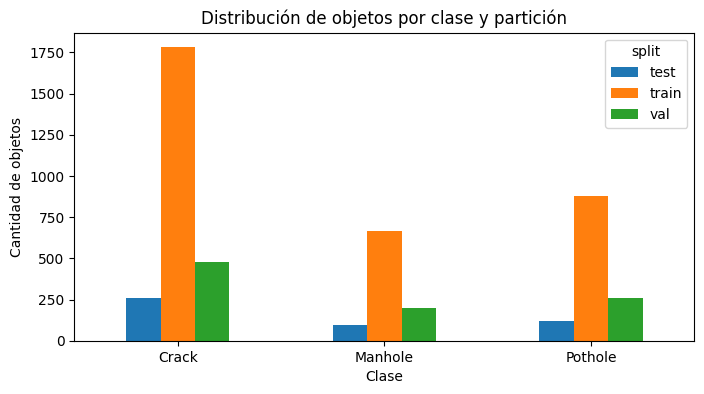

In [ ]:
def split_class_distribution(df: pd.DataFrame, split_name: str):
    return pd.DataFrame({
        "split": split_name,
        "class_id": [0, 1, 2],
        "class_name": [CLASS_NAMES[i] for i in [0, 1, 2]],
        "objects": [
            int(df["num_pothole"].sum()),
            int(df["num_crack"].sum()),
            int(df["num_manhole"].sum()),
        ],
        "images_with_class": [
            int(df["has_pothole"].sum()),
            int(df["has_crack"].sum()),
            int(df["has_manhole"].sum()),
        ],
    })

dist_by_split = pd.concat([
    split_class_distribution(train_df, "train"),
    split_class_distribution(val_df, "val"),
    split_class_distribution(test_df, "test"),
], ignore_index=True)

display(dist_by_split)

pivot_objects = dist_by_split.pivot(index="class_name", columns="split", values="objects")
display(pivot_objects)

pivot_objects.plot(kind="bar", figsize=(8, 4))
plt.title("Distribución de objetos por clase y partición")
plt.xlabel("Clase")
plt.ylabel("Cantidad de objetos")
plt.xticks(rotation=0)
plt.show()

# c) Preprocesamiento

El preprocesamiento prepara las imágenes antes de pasarlas al modelo.

El tamaño objetivo del notebook es `640 x 640`. Para imágenes más grandes que `640 x 640`, el comportamiento por defecto es:

1. `LongestMaxSize(max_size=640)`: reduce la imagen hasta que su lado más largo mida 640 px, manteniendo la proporción original.
2. `PadIfNeeded(640, 640)`: agrega padding hasta completar `640 x 640`.
3. Normalización con media y desvío de ImageNet.
4. Conversión a tensor.

Esto significa que **no se deforman las imágenes** y las cajas se actualizan automáticamente por Albumentations.

No se usa crop por defecto porque, en detección, un recorte puede dejar afuera o cortar objetos. Esto es especialmente riesgoso para clases minoritarias como `Crack` y `Manhole`, porque el modelo podría ver todavía menos ejemplos completos de esas clases.

De todos modos, queda configurado `PREPROCESS_MODE` para poder comparar:

- `"resize_pad"`: recomendado como base estable.
- `"safe_crop_resize"`: opción experimental solo para entrenamiento; intenta recortar preservando bounding boxes, pero debe verificarse visualmente.


# d) Data augmentation

El aumento de datos se aplica solamente al conjunto de entrenamiento.

Augmentations usadas:

- `HorizontalFlip`
- `RandomBrightnessContrast`
- `HueSaturationValue`
- `MotionBlur`
- `GaussNoise`

No se usa `VerticalFlip`, porque una calle invertida verticalmente no representa una situación realista.


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def get_resize_pad_transforms():
    return [
        A.LongestMaxSize(max_size=IMG_SIZE),
        A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, fill=(0, 0, 0)),
    ]


def get_safe_crop_resize_transforms():
    return [
        # Primero se limita el tamaño máximo para no trabajar con imágenes demasiado pesadas.
        A.LongestMaxSize(max_size=max(IMG_SIZE, 960)),
        # Crop seguro: intenta conservar las bounding boxes dentro del recorte.
        # Es experimental y conviene validar visualmente que no elimine demasiados objetos.
        A.RandomSizedBBoxSafeCrop(
            height=IMG_SIZE,
            width=IMG_SIZE,
            erosion_rate=0.2,
            p=0.7,
        ),
        A.LongestMaxSize(max_size=IMG_SIZE),
        A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, fill=(0, 0, 0)),
    ]


def get_base_train_preprocess(preprocess_mode: str):
    if preprocess_mode == "resize_pad":
        return get_resize_pad_transforms()
    if preprocess_mode == "safe_crop_resize":
        return get_safe_crop_resize_transforms()

    raise ValueError(f"PREPROCESS_MODE no soportado: {preprocess_mode}")


train_transform = A.Compose(
    [
        *get_base_train_preprocess(PREPROCESS_MODE),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.3),
        A.MotionBlur(blur_limit=3, p=0.2),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.2,
    ),
)

eval_transform = A.Compose(
    [
        *get_resize_pad_transforms(),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.2,
    ),
)

print("Modo de preprocesamiento train:", PREPROCESS_MODE)
print("Transformaciones de train:")
print(train_transform)

print("\nTransformaciones de validación/test:")
print(eval_transform)


Modo de preprocesamiento train: resize_pad
Transformaciones de train:
Compose([
  LongestMaxSize(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, max_size=640, max_size_hw=None),
  PadIfNeeded(p=1.0, border_mode=0, fill=(0.0, 0.0, 0.0), fill_mask=0.0, min_height=640, min_width=640, pad_height_divisor=None, pad_width_divisor=None, padding=0, position='center'),
  HorizontalFlip(p=0.5),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  HueSaturationValue(p=0.3, hue_shift_limit=(-20.0, 20.0), sat_shift_limit=(-30.0, 30.0), val_shift_limit=(-20.0, 20.0)),
  MotionBlur(p=0.2, allow_shifted=True, angle_range=(0.0, 360.0), blur_limit=(3, 3), direction_range=(-1.0, 1.0)),
  GaussNoise(p=0.2, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0

# e) Balanceo de clases y pesos para la función de pérdida

El dataset puede quedar desbalanceado entre `Pothole`, `Crack` y `Manhole`. Para que el modelo no aprenda principalmente de la clase con más ejemplos, se aplican dos estrategias complementarias:

1. **Pesos de clase para la pérdida:** las clases con menos objetos reciben mayor peso. Si el modelo se equivoca en `Crack` o `Manhole`, el error pesa más que en una clase abundante.
2. **Muestreo balanceado en el `train_loader`:** se usa `WeightedRandomSampler` para que las imágenes con clases minoritarias aparezcan con mayor frecuencia durante el entrenamiento.

Importante: este notebook todavía no define un modelo completo de detección ni una función de pérdida final de entrenamiento. Por eso se deja preparada una `CrossEntropyLoss` ponderada para la parte de clasificación del detector. Si luego se usa un modelo tipo Faster R-CNN/RetinaNet de `torchvision`, hay que integrar estos pesos en la pérdida de clasificación correspondiente o adaptar la cabeza del modelo.


In [ ]:
def compute_class_weights_from_train_df(
    df: pd.DataFrame,
    class_names: dict,
    power: float = CLASS_WEIGHT_POWER,
    max_weight: float = MAX_CLASS_WEIGHT,
):
    """Calcula pesos inversamente proporcionales a la cantidad de objetos por clase.

    La fórmula base es:
        peso_clase = total_objetos / (n_clases * objetos_de_la_clase)

    Después se normaliza para que el promedio sea cercano a 1.
    `power` permite aumentar o suavizar el castigo sobre clases minoritarias.
    """
    class_count_columns = {
        0: "num_pothole",
        1: "num_crack",
        2: "num_manhole",
    }

    counts = torch.tensor(
        [float(df[class_count_columns[class_id]].sum()) for class_id in class_names.keys()],
        dtype=torch.float32,
    )

    safe_counts = torch.clamp(counts, min=1.0)
    total_objects = safe_counts.sum()
    num_classes = len(class_names)

    weights = total_objects / (num_classes * safe_counts)
    weights = weights.pow(power)
    weights = weights / weights.mean()
    weights = torch.clamp(weights, max=max_weight)

    return weights, counts


def build_image_sampling_weights(
    df: pd.DataFrame,
    class_weights: torch.Tensor,
    no_object_weight: float = NO_OBJECT_SAMPLE_WEIGHT,
):
    """Asigna un peso a cada imagen para usar en WeightedRandomSampler.

    Si una imagen contiene varias clases, se toma el mayor peso de las clases presentes.
    Así, una imagen que contiene una clase minoritaria tiene más chances de aparecer en train.
    """
    class_count_columns = {
        0: "num_pothole",
        1: "num_crack",
        2: "num_manhole",
    }

    image_weights = []

    for _, row in df.iterrows():
        present_class_weights = []

        for class_id, column in class_count_columns.items():
            if row[column] > 0:
                present_class_weights.append(float(class_weights[class_id].item()))

        if len(present_class_weights) == 0:
            image_weights.append(no_object_weight)
        else:
            image_weights.append(max(present_class_weights))

    return torch.as_tensor(image_weights, dtype=torch.double)


class_weights, train_class_counts = compute_class_weights_from_train_df(train_df, CLASS_NAMES)
train_sample_weights = build_image_sampling_weights(train_df.reset_index(drop=True), class_weights)

train_sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

class_balance_df = pd.DataFrame({
    "class_id": list(CLASS_NAMES.keys()),
    "class_name": [CLASS_NAMES[class_id] for class_id in CLASS_NAMES.keys()],
    "train_objects": train_class_counts.numpy().astype(int),
    "loss_weight": class_weights.numpy().round(4),
})

display(class_balance_df)

print("Pesos para CrossEntropyLoss:", class_weights)
print("\nInterpretación:")
print("- Mayor peso = mayor castigo si el modelo se equivoca en esa clase.")
print("- Si Crack o Manhole tienen menos objetos, deberían recibir un peso mayor.")
print("- El train_loader usará WeightedRandomSampler, por eso no debe usar shuffle=True.")

weighted_cross_entropy_loss = nn.CrossEntropyLoss(weight=class_weights)

print("\nFunción de pérdida preparada:")
print(weighted_cross_entropy_loss)
print("\nEn entrenamiento real, mover a device así:")
print("criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))")


,class_id,class_name,train_objects,loss_weight
0,0,Pothole,877,1.0678
1,1,Crack,1780,0.5261
2,2,Manhole,666,1.4061


Pesos para CrossEntropyLoss: tensor([1.0678, 0.5261, 1.4061])

Interpretación:
- Mayor peso = mayor castigo si el modelo se equivoca en esa clase.
- Si Crack o Manhole tienen menos objetos, deberían recibir un peso mayor.
- El train_loader usará WeightedRandomSampler, por eso no debe usar shuffle=True.

Función de pérdida preparada:
CrossEntropyLoss()

En entrenamiento real, mover a device así:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


# f) Verificación final

Se crea un `Dataset` personalizado de PyTorch y luego los `DataLoader` de entrenamiento, validación y test.

Cada muestra devuelve:

```python
image, target
```

donde `target` contiene:

```python
{
    "boxes": Tensor[N, 4],
    "labels": Tensor[N],
    "image_id": Tensor[1],
}
```

Esto permite verificar que las imágenes, etiquetas y bounding boxes estén correctamente alineadas.

El `train_loader` usa `WeightedRandomSampler` para reforzar las clases minoritarias. Por eso, en entrenamiento, `shuffle=False`: el muestreo balanceado reemplaza al mezclado aleatorio simple.


In [ ]:
def yolo_to_xyxy_abs(boxes_yolo, image_width: int, image_height: int):
    """Convierte cajas YOLO normalizadas a xyxy absolutas, con clip final al tamaño real."""
    boxes_xyxy = []

    for x_center, y_center, width, height in boxes_yolo:
        clipped = clip_yolo_bbox(x_center, y_center, width, height)
        if clipped is None:
            continue

        x_center, y_center, width, height = clipped

        x_center *= image_width
        y_center *= image_height
        width *= image_width
        height *= image_height

        x_min = x_center - width / 2
        y_min = y_center - height / 2
        x_max = x_center + width / 2
        y_max = y_center + height / 2

        x_min = min(max(x_min, 0.0), float(image_width))
        y_min = min(max(y_min, 0.0), float(image_height))
        x_max = min(max(x_max, 0.0), float(image_width))
        y_max = min(max(y_max, 0.0), float(image_height))

        if x_max <= x_min or y_max <= y_min:
            continue

        boxes_xyxy.append([x_min, y_min, x_max, y_max])

    return boxes_xyxy


class RoadDamageDataset(Dataset):
    def __init__(self, csv_path: Path, project_root: Path, transform=None, label_offset: int = 0):
        self.csv_path = Path(csv_path)
        self.df = pd.read_csv(self.csv_path)
        self.project_root = Path(project_root)
        self.transform = transform
        self.label_offset = label_offset

        # Nota importante para Semana 3:
        # Los modelos de detección de torchvision reservan la etiqueta 0 para background.
        # Por eso, para entrenar Faster R-CNN se instancia este Dataset con label_offset=1.
        # Para visualización didáctica se mantiene label_offset=0.

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.project_root / str(row["image_path"])

        raw_label_path = row.get("label_path", "")
        if pd.isna(raw_label_path) or str(raw_label_path).strip() == "":
            label_path = None
        else:
            label_path = self.project_root / str(raw_label_path)

        image = np.array(Image.open(image_path).convert("RGB"))

        objects = read_yolo_label(label_path)
        bboxes = [[obj["x_center"], obj["y_center"], obj["width"], obj["height"]] for obj in objects]
        class_labels = [obj["class_id"] for obj in objects]

        # Evita errores por x_max/y_max apenas mayores a 1.0.
        bboxes, class_labels = sanitize_yolo_bboxes_and_labels(bboxes, class_labels)

        if self.transform is not None:
            transformed = self.transform(
                image=image,
                bboxes=bboxes,
                class_labels=class_labels,
            )
            image = transformed["image"]
            bboxes = transformed["bboxes"]
            class_labels = transformed["class_labels"]

        # Algunas transformaciones pueden eliminar o recortar cajas.
        bboxes, class_labels = sanitize_yolo_bboxes_and_labels(bboxes, class_labels)

        if isinstance(image, np.ndarray):
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        _, height, width = image.shape

        if len(bboxes) > 0:
            boxes_xyxy = yolo_to_xyxy_abs(bboxes, width, height)
            valid_count = min(len(boxes_xyxy), len(class_labels))
            boxes_xyxy = boxes_xyxy[:valid_count]
            class_labels = class_labels[:valid_count]

            boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
            labels = torch.as_tensor([int(label) + self.label_offset for label in class_labels], dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        return image, target


def detection_collate_fn(batch):
    """Collate necesario para detección, porque cada imagen puede tener distinta cantidad de cajas."""
    images, targets = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, list(targets)


train_dataset = RoadDamageDataset(TRAIN_CSV, PROJECT_ROOT, transform=train_transform)
val_dataset = RoadDamageDataset(VAL_CSV, PROJECT_ROOT, transform=eval_transform)
test_dataset = RoadDamageDataset(TEST_CSV, PROJECT_ROOT, transform=eval_transform)

print("Tamaños:")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

sample_image, sample_target = train_dataset[0]
print("\nSample image shape:", sample_image.shape)
print("Sample target:", sample_target)


Tamaños:
Train: 1406
Val: 402
Test: 201

Sample image shape: torch.Size([3, 640, 640])
Sample target: {'boxes': tensor([[120.9997, 340.9999, 358.0000, 466.9999],
        [368.0000, 374.0000, 547.0003, 475.9999]]), 'labels': tensor([1, 1]), 'image_id': tensor([0])}


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

images_batch, targets_batch = next(iter(train_loader))

print("Batch de train balanceado:")
print("images_batch.shape:", images_batch.shape)
print("Cantidad de targets:", len(targets_batch))
print("Target del primer elemento:", targets_batch[0])
print("Rango de valores normalizados:")
print("mínimo:", images_batch.min().item())
print("máximo:", images_batch.max().item())

batch_labels = []
for target in targets_batch:
    batch_labels.extend([int(label) for label in target["labels"]])

print("\nDistribución de clases dentro del batch muestreado:")
print({CLASS_NAMES[class_id]: batch_labels.count(class_id) for class_id in CLASS_NAMES})


Batch de train balanceado:
images_batch.shape: torch.Size([8, 3, 640, 640])
Cantidad de targets: 8
Target del primer elemento: {'boxes': tensor([[278.9997, 376.9999, 335.0003, 398.0001]]), 'labels': tensor([0]), 'image_id': tensor([73])}
Rango de valores normalizados:
mínimo: -2.1179039478302
máximo: 2.6399998664855957

Distribución de clases dentro del batch muestreado:
{'Pothole': 8, 'Crack': 6, 'Manhole': 4}


In [ ]:
def denormalize_image(tensor_img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor_img.detach().cpu().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img


def show_image_with_boxes(tensor_img, target, title=None):
    img = denormalize_image(tensor_img)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)

    boxes = target["boxes"].detach().cpu().numpy()
    labels = target["labels"].detach().cpu().numpy()

    ax = plt.gca()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(y1 - 5, 0),
            CLASS_NAMES[int(label)],
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7),
        )

    if title:
        plt.title(title)

    plt.axis("off")
    plt.show()

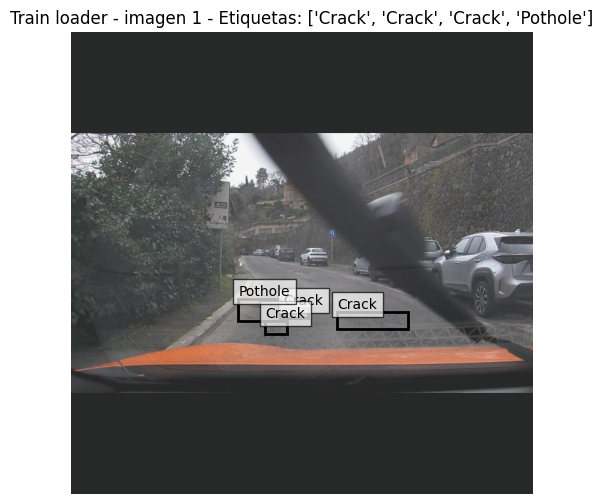

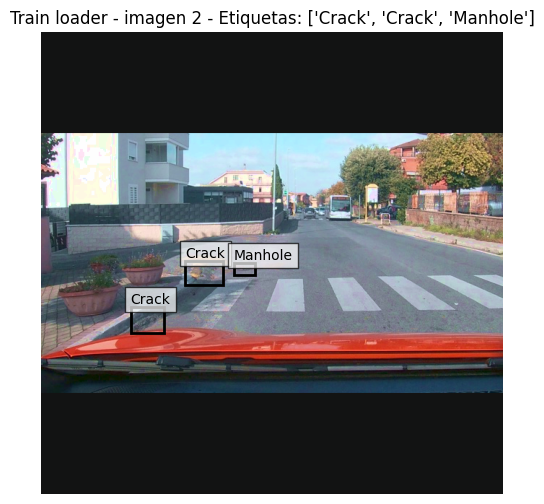

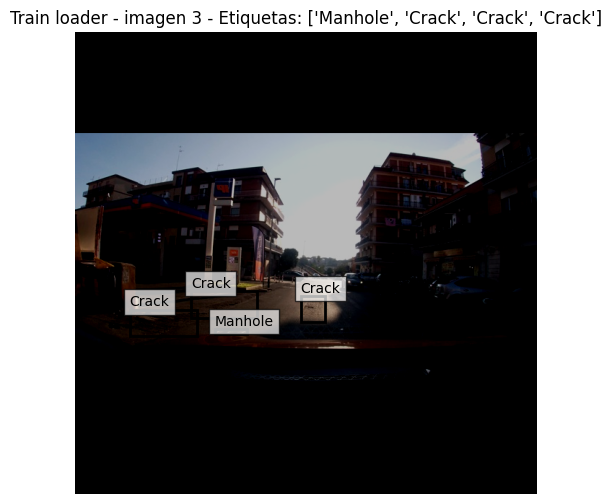

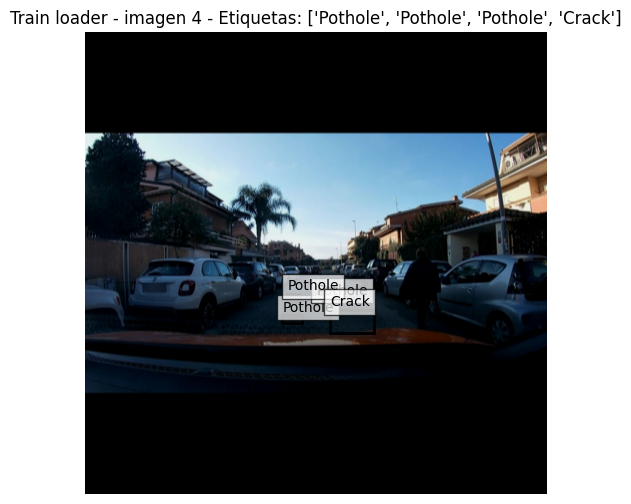

In [ ]:
# Visualización de augmentations usando directamente el train_loader.

images_batch, targets_batch = next(iter(train_loader))

positive_indices_in_batch = [
    i for i, target in enumerate(targets_batch)
    if len(target["labels"]) > 0
]

if len(positive_indices_in_batch) == 0:
    print("El primer batch no tiene objetos anotados. Probá ejecutar esta celda otra vez para tomar otro batch del train_loader.")
else:
    num_to_show = min(4, len(positive_indices_in_batch))

    for shown_idx, batch_idx in enumerate(positive_indices_in_batch[:num_to_show], start=1):
        labels_names = [CLASS_NAMES[int(label)] for label in targets_batch[batch_idx]["labels"]]
        show_image_with_boxes(
            images_batch[batch_idx],
            targets_batch[batch_idx],
            title=f"Train loader - imagen {shown_idx} - Etiquetas: {labels_names}",
        )
